In [1]:
import numpy as np
from PRGDS_Interval_Tensor import PRGDS_tensor
from tqdm.auto import tqdm
import torch
import matplotlib.pyplot as plt

In [2]:
qualitative_data = np.load('/home/HuangRui/PointProcess/NodeGroup/data/icews_tensor_reconstruct_120101050.npz', allow_pickle=True)

In [13]:
burnin = 20
maxiter = 10 
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : torch.tensor(qualitative_data['data']),
'K' : 10, # latent components
'S' : 1, # sub-intervals
'parallel' : False
}

model = PRGDS_tensor(**params)
model.phi[0] = torch.eye(10)
model.phi[1] = torch.eye(10)
transition_collection = []

for iter in tqdm(range(burnin+maxiter)):
    model.sample_n()
    model.sample_h()
    model.sample_the()
    model.sample_lam()
    model.sample_delt()
    model.sample_g()
    model.sample_gam()
    model.sample_beta()
    model.sample_phi()
    model.sample_pi()

    if iter+1 > burnin:
        transition_collection.append(model.pi.clone())

  0%|          | 0/30 [00:00<?, ?it/s]

sample_n took 39.6306 seconds
sample_h took 0.7177 seconds
sample_the took 0.0012 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0017 seconds
sample_g took 0.0010 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0482 seconds
sample_pi took 0.0015 seconds
sample_n took 39.3213 seconds
sample_h took 0.7281 seconds
sample_the took 0.0010 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0011 seconds
sample_g took 0.0009 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0468 seconds
sample_pi took 0.0016 seconds
sample_n took 39.1233 seconds
sample_h took 0.7255 seconds
sample_the took 0.0010 seconds
sample_lam took 0.0003 seconds
sample_delt took 0.0008 seconds
sample_g took 0.0009 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0507 seconds
sample_pi took 0.0015 seconds
sample_n took 37.8686 seconds
sample_h took 0.7248 seconds
sample_the took 0.0010 

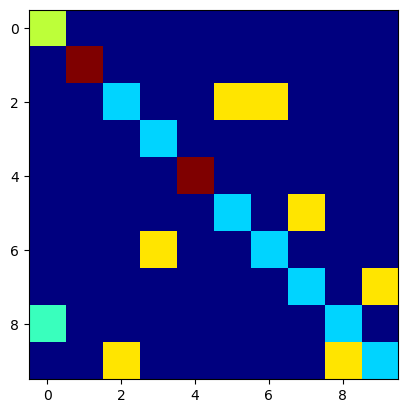

In [17]:
%matplotlib inline
plt.imshow(model.pi[0] + torch.eye(10)*0.5, cmap = 'jet')
plt.show()